In [1]:
import numpy as np

In [2]:
#Lattice Parameters & Physical Constants
# Tuples: Fixed lattice vectors (immutable)
a1 = (0.543, 0.0)  # [nm]
a2 = (0.0, 0.543)  # [nm]

#Dictionary_Material & Optical properties
silicon = {
    "lattice_constant": 0.543,  # nm
    "refractive_index": 3.42,
    "wavelength": 0.633,  # um (He-Ne laser)
}

In [3]:
print("vector", a1, silicon)
print(f"sili: {silicon['wavelength']}")

vector (0.543, 0.0) {'lattice_constant': 0.543, 'refractive_index': 3.42, 'wavelength': 0.633}
sili: 0.633


In [8]:
#1D Atomic Chains & 2D Optical Grids
Natoms= 5
x_chain=np.linspace(0, (Natoms-1)* silicon['lattice_constant'], Natoms)
x=np.linspace(-10, 10, 5)
y=np.linspace(-10, 10, 5)
X, Y = np.meshgrid(x, y) #sparse=True: into np.meshgrid() to return memory-efficient sparse grids that leverage NumPy broadcasting instead of copying data
print("atom position(nm):\n", x_chain)

atom position(nm):
 [0.    0.543 1.086 1.629 2.172]


In [9]:
X

array([[-10.,  -5.,   0.,   5.,  10.],
       [-10.,  -5.,   0.,   5.,  10.],
       [-10.,  -5.,   0.,   5.,  10.],
       [-10.,  -5.,   0.,   5.,  10.],
       [-10.,  -5.,   0.,   5.,  10.]])

In [10]:
Y

array([[-10., -10., -10., -10., -10.],
       [ -5.,  -5.,  -5.,  -5.,  -5.],
       [  0.,   0.,   0.,   0.,   0.],
       [  5.,   5.,   5.,   5.,   5.],
       [ 10.,  10.,  10.,  10.,  10.]])

In [18]:
# Calculate distance from origin r = sqrt(x^2 + y^2) for all 25 points at once
R = np.sqrt(X**2 + Y**2)
# Calculate a 2D Gaussian beam intensity I(x,y) = exp(-r^2)
Intensity = np.exp(-R**2)
Intensity,R

(array([[1.38389653e-87, 5.16642063e-55, 3.72007598e-44, 5.16642063e-55,
         1.38389653e-87],
        [5.16642063e-55, 1.92874985e-22, 1.38879439e-11, 1.92874985e-22,
         5.16642063e-55],
        [3.72007598e-44, 1.38879439e-11, 1.00000000e+00, 1.38879439e-11,
         3.72007598e-44],
        [5.16642063e-55, 1.92874985e-22, 1.38879439e-11, 1.92874985e-22,
         5.16642063e-55],
        [1.38389653e-87, 5.16642063e-55, 3.72007598e-44, 5.16642063e-55,
         1.38389653e-87]]),
 array([[14.14213562, 11.18033989, 10.        , 11.18033989, 14.14213562],
        [11.18033989,  7.07106781,  5.        ,  7.07106781, 11.18033989],
        [10.        ,  5.        ,  0.        ,  5.        , 10.        ],
        [11.18033989,  7.07106781,  5.        ,  7.07106781, 11.18033989],
        [14.14213562, 11.18033989, 10.        , 11.18033989, 14.14213562]]))

In [12]:
N = 5  # Number of atoms in the chain
C = 1.0  # Spring constant between atoms

# Small displacement of each atom from equilibrium u_i
u = np.array([0.1, -0.05, 0.02, 0.08, -0.01])
F = np.zeros(N)  # Net force on each atom

# Loop over each atom to calculate force from left and right neighbors
for i in range(N):
    left = (i - 1) % N  # Periodic boundary condition for left neighbor
    right = (i + 1) % N  # Periodic boundary condition for right neighbor

    # Hooke's Law: F_i = C * (u_{i+1} + u_{i-1} - 2*u_i)
    F[i] = C * (u[right] + u[left] - 2 * u[i])

print("Displacements u:", u)
print("Net forces F:", F)

Displacements u: [ 0.1  -0.05  0.02  0.08 -0.01]
Net forces F: [-0.26  0.22 -0.01 -0.15  0.2 ]


In [13]:
dt = 0.01  # Time step
t = 0.0  # Current time
t_max = 0.05  # Stop condition

# Time-stepping loop
while t < t_max:
    # Update position based on velocity (simple Euler step: u_new = u + v * dt)
    u = u + 0.1 * F * dt
    t += dt  # Increment time

print(f"Final time: {t:.2f} s")
print("Updated displacements:", np.round(u, 4))

Final time: 0.05 s
Updated displacements: [ 0.0987 -0.0489  0.02    0.0793 -0.009 ]


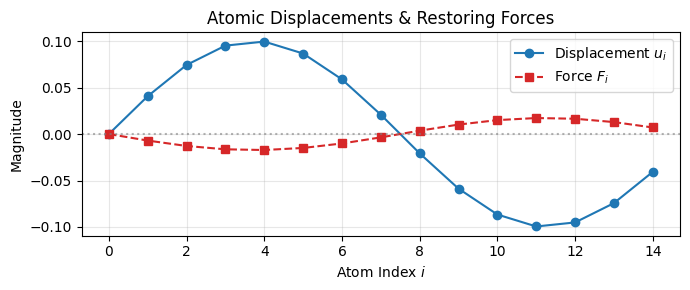

In [16]:
# 1. Setup lattice parameters
N, C = 15, 1.0  # N = 15 atoms, C = spring constant
atoms = np.arange(N)

# 2. Sinusoidal atomic displacement: u_i = A * sin(2*pi*i / N)
u = 0.1 * np.sin(2 * np.pi * atoms / N)
F = np.zeros(N)

# 3. Compute force F_i using a for loop with PBC
for i in range(N):
    left = (i - 1) % N  # Left neighbor index with PBC
    right = (i + 1) % N  # Right neighbor index with PBC
    F[i] = C * (u[right] + u[left] - 2 * u[i])  # Hooke's Law

# 4. Plot atomic displacements u_i and restoring forces F_i
plt.figure(figsize=(7, 3))
plt.plot(atoms, u, "o-", label="Displacement $u_i$", color="tab:blue")
plt.plot(atoms, F, "s--", label="Force $F_i$", color="tab:red")
plt.axhline(0, color="gray", linestyle=":", alpha=0.6)
plt.xlabel("Atom Index $i$")
plt.ylabel("Magnitude")
plt.title("Atomic Displacements & Restoring Forces")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

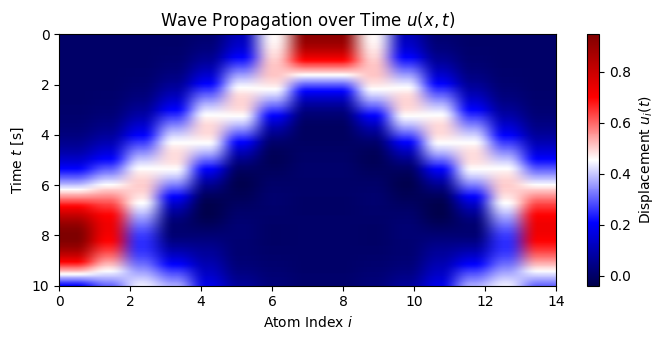

In [19]:
# 1. Simulation parameters
dt, t_max, m = 0.05, 10.0, 1.0
t = 0.0

# 2. Initial Gaussian displacement profile u_i(0)
u = np.exp(-0.5 * ((atoms - N / 2) / 1.2) ** 2)
v = np.zeros(N)  # Initial velocity v_i(0) = 0
history = []

# 3. Time integration while loop (t < t_max)
while t < t_max:
    history.append(u.copy())

    # Calculate net forces F_i(t)
    F = np.zeros(N)
    for i in range(N):
        left, right = (i - 1) % N, (i + 1) % N
        F[i] = C * (u[right] + u[left] - 2 * u[i])

    # Euler-Cromer update equations
    v += (F / m) * dt  # Velocity update: v(t + dt)
    u += v * dt  # Position update: u(t + dt)
    t += dt  # Time step increment

# 4. Plot space-time wave propagation map u(x, t)
plt.figure(figsize=(7, 3.5))
plt.imshow(history, aspect="auto", extent=[0, N - 1, t_max, 0], cmap="seismic")
plt.colorbar(label="Displacement $u_i(t)$")
plt.xlabel("Atom Index $i$")
plt.ylabel("Time $t$ [s]")
plt.title("Wave Propagation over Time $u(x, t)$")
plt.tight_layout()
plt.show()

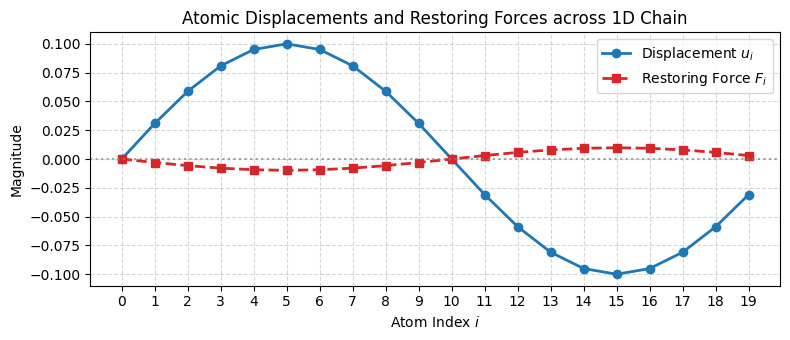

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# System configuration
N = 20  # Number of atoms in the chain
C = 1.0  # Spring constant
atom_indices = np.arange(N)

# Displacements u_i (a sinusoidal standing wave distortion)
u = 0.1 * np.sin(2 * np.pi * atom_indices / N)
F = np.zeros(N)  # Pre-allocate force array

# Loop over atoms using periodic boundary conditions
for i in range(N):
    left = (i - 1) % N  # Left neighbor index (wrap around at i = 0)
    right = (i + 1) % N  # Right neighbor index (wrap around at i = N-1)

    # Hooke's law for 1D spring network
    F[i] = C * (u[right] + u[left] - 2 * u[i])

# Plotting initial displacements and restoring forces
plt.figure(figsize=(8, 3.5))
plt.plot(
    atom_indices,
    u,
    "o-",
    label="Displacement $u_i$",
    color="tab:blue",
    linewidth=2,
)
plt.plot(
    atom_indices,
    F,
    "s--",
    label="Restoring Force $F_i$",
    color="tab:red",
    linewidth=2,
)
plt.axhline(0, color="gray", linestyle=":", alpha=0.7)
plt.xlabel("Atom Index $i$")
plt.ylabel("Magnitude")
plt.title("Atomic Displacements and Restoring Forces across 1D Chain")
plt.xticks(atom_indices)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

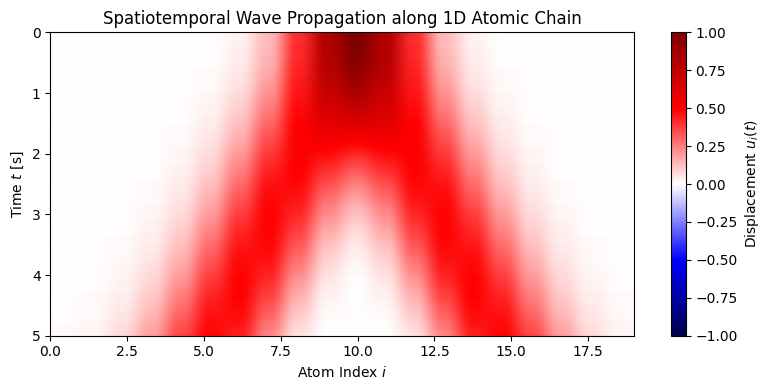

In [15]:
# Simulation parameters
dt = 0.02  # Time step size [s]
t = 0.0  # Initial time
t_max = 5.0  # Total simulation run time
m = 1.0  # Atomic mass

# Initial state vectors
u = np.exp(-0.5 * ((atom_indices - N / 2) / 1.5) ** 2)  # Gaussian displacement packet
v = np.zeros(N)  # Initial velocity = 0

# Arrays to store history for plotting
history_u = []
history_t = []

# Time integration loop using simple Euler-Cromer method
while t < t_max:
    history_u.append(u.copy())
    history_t.append(t)

    # 1. Compute forces with periodic boundary conditions
    F = np.zeros(N)
    for i in range(N):
        left = (i - 1) % N
        right = (i + 1) % N
        F[i] = C * (u[right] + u[left] - 2 * u[i])

    # 2. Update velocity and position
    v += (F / m) * dt
    u += v * dt

    t += dt

# Convert history list to 2D matrix (time rows, spatial columns)
history_u = np.array(history_u)

# Plot space-time propagation (Heatmap/Contour)
plt.figure(figsize=(8, 4))
im = plt.imshow(
    history_u,
    aspect="auto",
    extent=[0, N - 1, t_max, 0],
    cmap="seismic",
    vmin=-1.0,
    vmax=1.0,
)
plt.colorbar(im, label="Displacement $u_i(t)$")
plt.xlabel("Atom Index $i$")
plt.ylabel("Time $t$ [s]")
plt.title("Spatiotemporal Wave Propagation along 1D Atomic Chain")
plt.tight_layout()
plt.show()
